<a href="https://colab.research.google.com/github/TR2Theo/fft-case-studies-template/blob/main/1.1Sunspot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget https://github.com/TR2Theo/fft-case-studies-template/blob/main/data/sunspots.csv

--2026-05-28 06:33:31--  https://github.com/TR2Theo/fft-case-studies-template/blob/main/data/sunspots.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘sunspots.csv.1’

sunspots.csv.1          [ <=>                ] 621.48K  --.-KB/s    in 0.1s    

2026-05-28 06:33:32 (4.70 MB/s) - ‘sunspots.csv.1’ saved [636391]



--2026-05-28 12:07:51--  https://raw.githubusercontent.com/TR2Theo/fft-case-studies-template/main/data/sunspots.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71184 (70K) [text/plain]
Saving to: ‘sunspots.csv’

sunspots.csv        100%[===================>]  69.52K  --.-KB/s    in 0.01s   

2026-05-28 12:07:51 (5.80 MB/s) - ‘sunspots.csv’ saved [71184/71184]



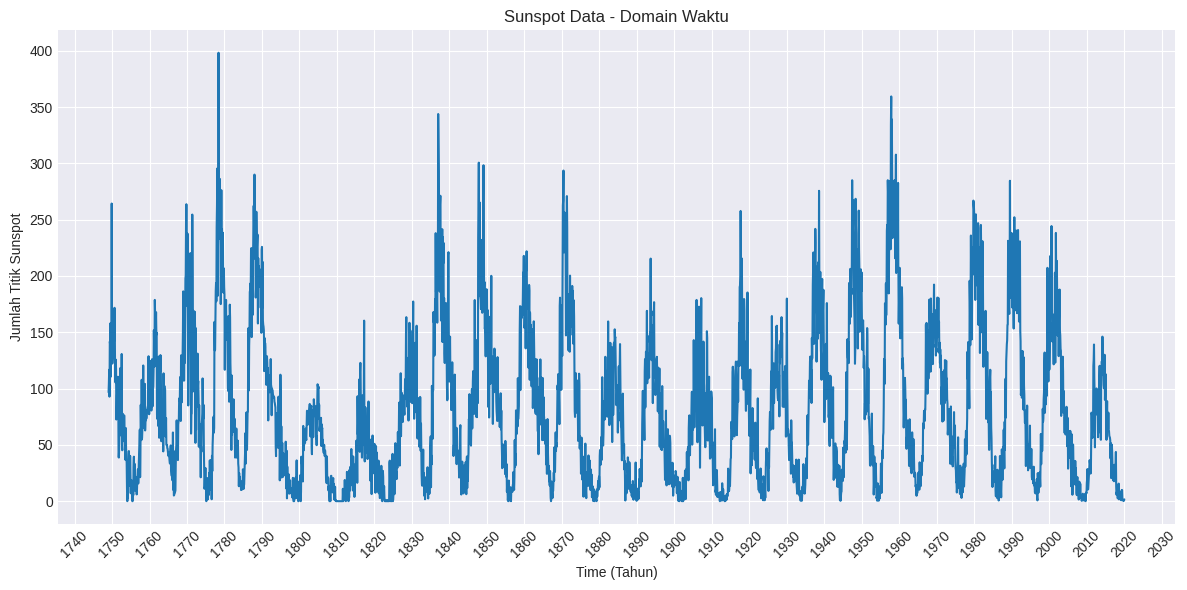

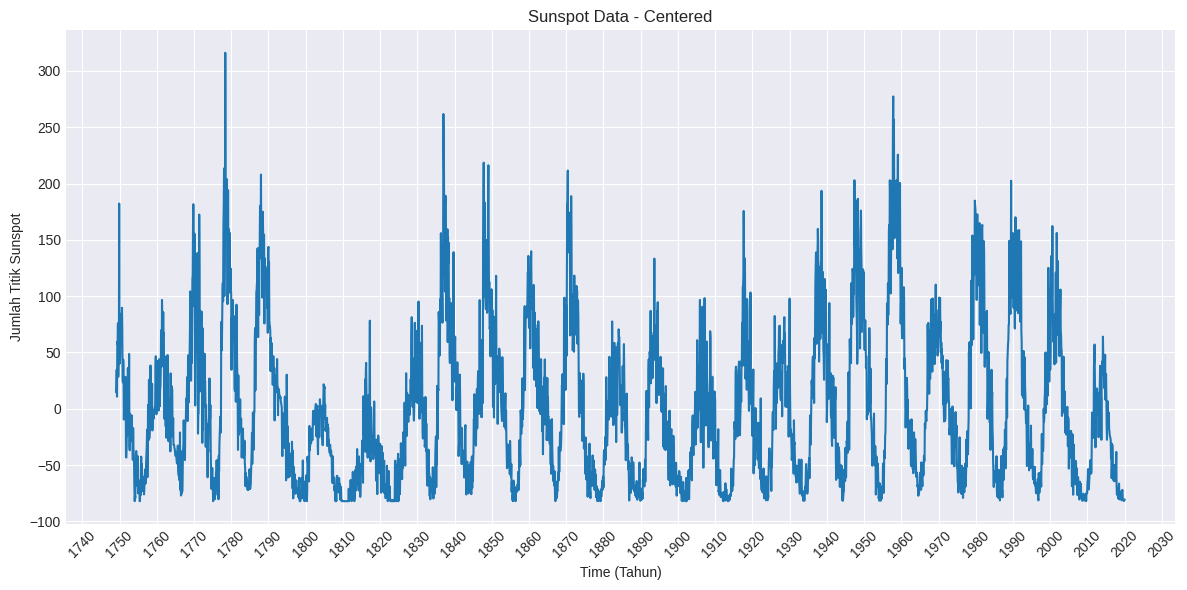

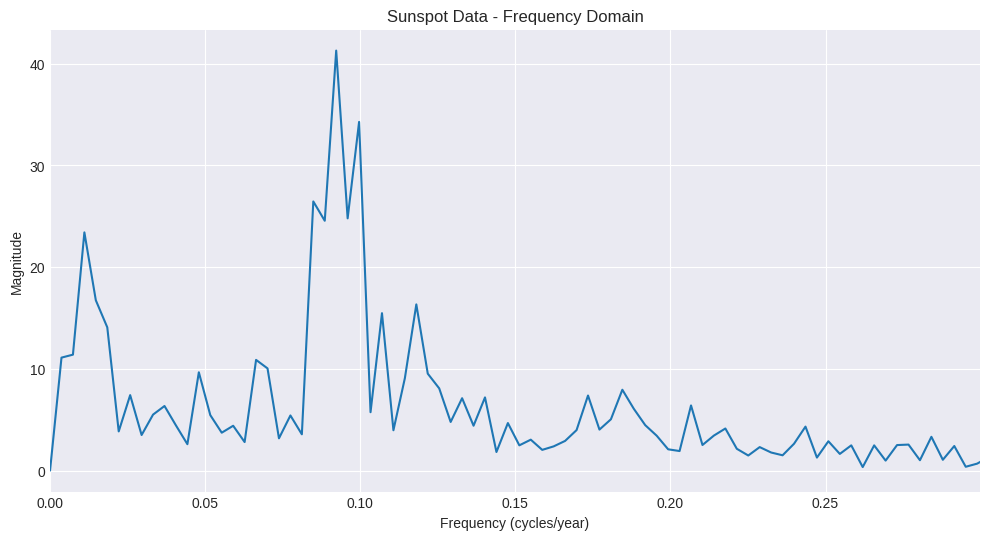

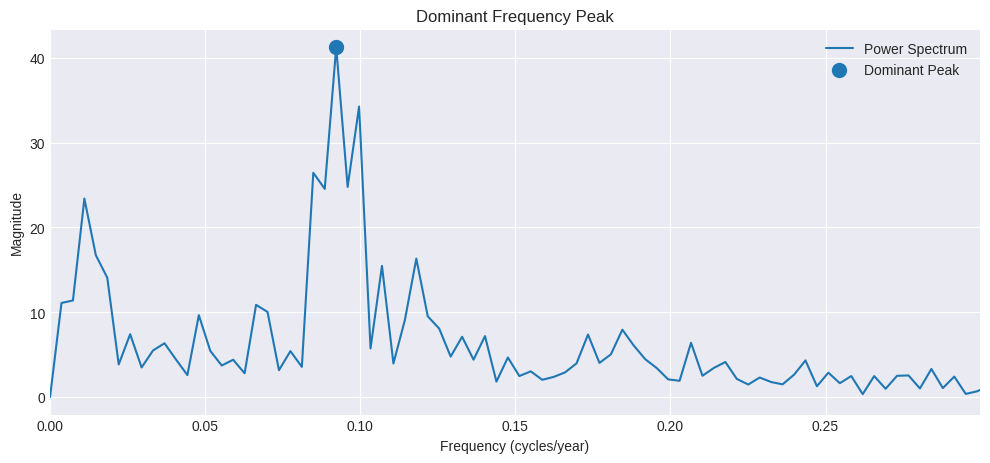

POWER SPECTRUM RESULT 1
FFT PEAK DETECTION RESULT
Dominant Frequency            : 0.0923 cycles/year
Computed Solar Cycle Period   : 10.84 years
POWER SPECTRUM RESULT 2
FFT PEAK DETECTION RESULT
Dominant Frequency            : 0.0996 cycles/year
Computed Solar Cycle Period   : 10.04 years
POWER SPECTRUM RESULT 3
FFT PEAK DETECTION RESULT
Dominant Frequency            : 0.0849 cycles/year
Computed Solar Cycle Period   : 11.78 years


In [37]:
# Memasukkan librari untuk komputasi saintifik (Numpy, plot, dan Panda untuk baca file .csv)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import pandas as pd

# mengatur style plot sesuai dengan template
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# --- TASK 1: Memasukkan dan Mem-plot data dalam domain frekuensi-waktu---
!wget -O sunspots.csv https://raw.githubusercontent.com/TR2Theo/fft-case-studies-template/main/data/sunspots.csv # Pastikan CSV mentah diunduh, karena wget sebelumnya mungkin telah mengunduh HTML
df = pd.read_csv("sunspots.csv") # 1. Memasukkan data sunspot.csv dengan panda
time = pd.to_datetime(df["Date"]) # 2. Ekstrak array waktu (t) dan array sinyal (y)
y = df["Monthly Mean Total Sunspot Number"].values
fig, ax = plt.subplots()

ax.plot(time, y)

# Judul dan label
ax.set_title("Sunspot Data - Domain Waktu")
ax.set_xlabel("Time (Tahun)")
ax.set_ylabel("Jumlah Titik Sunspot")

# Mengatur label tahun agar sesuai posisi datetime
ax.xaxis.set_major_locator(mdates.YearLocator(10))
# label tiap 10 tahun

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Rotasi label tahun
plt.xticks(rotation=45)

# Grid dan layout
plt.grid(True)
plt.tight_layout()
plt.savefig('Sunspot_Data-Domain_Waktu.png', dpi=300)
plt.show()

# --- TUGAS 2: Lepas komponen DC(direct current) ---
Mean = np.mean(y) # 1. Hitung rata-rata susunan bintik matahari.
y_centered = y - Mean   # 2. Buat array baru untuk y yang dipusatkan
# 3. Plot data terpusat untuk memverifikasi bahwa data tersebut berosilasi di sekitar nol.
fig, ax = plt.subplots()

ax.plot(time, y_centered)

# Judul dan label
ax.set_title("Sunspot Data - Centered")
ax.set_xlabel("Time (Tahun)")
ax.set_ylabel("Jumlah Titik Sunspot")
# Mengatur label tahun agar sesuai posisi datetime
ax.xaxis.set_major_locator(mdates.YearLocator(10))
# label tiap 10 tahun

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Rotasi label tahun
plt.xticks(rotation=45)

# Grid dan layout
plt.grid(True)
plt.tight_layout()
plt.savefig('Sunspot_Data-Centered.png', dpi=300)
plt.show()

# --- TASK 3: Hitung FFT dan Spektrum Daya ---
N = len(y) # 1. Define N (number of samples) and
dt = 1/12  #dt (sampling interval in years).
fft_result = np.fft.fft(y_centered) # 2. menghitung FFT menggunakan np.fft.fft()
freq_bins = np.fft.fftfreq(N, d=dt) # 3. menghitung kelompok rentang frekuensi tertentu yang digunakan untuk memecah sinyal kompleks menggunakan np.fft.fftfreq()

# 4. Hitung spektrum magnitudo positif (Daya). Ingatlah untuk hanya menjaga separuh frekuensi positif (hingga batas Nyquist).
positive_mask = freq_bins >= 0
positive_freq = freq_bins[positive_mask]
magnitude = np.abs(fft_result[positive_mask])
# ------------------------------------------------
# Normalisasi Power spektrum
# ------------------------------------------------
power = (2 / N)*magnitude

# penentuan filter frekuensi rendah untuk menentukan batas dalam plt.xlim()
n_classes = 20 #jumlah kelas tiap data

# frekuensi tiap interval
bins = np.linspace(
    positive_freq.min(),
    positive_freq.max(),
    n_classes + 1
)
# menyimpan total power tiap kelas
class_power = []

# =========================================================
# menghitung total power tiap kelas
# =========================================================

for i in range(n_classes):

    mask = (
        (positive_freq >= bins[i]) &
        (positive_freq < bins[i+1])
    )

    total_power = np.sum(power[mask])

    class_power.append(total_power)

class_power = np.array(class_power)

# =========================================================
# Mencari kelas yang power spetrumnya dominan
# =========================================================
dominant_idx = np.argmax(class_power)
upper_bound = bins[dominant_idx + 1] #batas atas kelas yang nilai powernya dominan

# --- TASK 4: Visualisasi domain frekuensi ---
plt.plot(positive_freq, power) # 1. Plot the power spectrum.
plt.title("Sunspot Data - Frequency Domain")
# 2. menamakan label x-axis sebagai "Frequency (cycles/year)" dan y-axis sebagai "Magnitude".
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude")
plt.xlim(0, upper_bound) # 3. menggunakan plt.xlim() untuk memfilter di frekuensi rendah
plt.grid(True)
plt.savefig('power_spektrum.png', dpi=300)
plt.show()

# --- TASK 5: Program untuk mendeteksi puncak frekuensi ---
# mengabaikan frekuensi 0 agar tidak mendektesi komponen DC
peak_index = np.argmax(power[1:]) + 1
# Frekuensi dominan
dominant_frequency = positive_freq[peak_index]
# Menghitung periode dominan
dominant_period = 1 / dominant_frequency
# Plot frekuensi-time domain dengan menandai titik power spektrum tertinggi
plt.figure(figsize=(12,5))

plt.plot(positive_freq, power, label='Power Spectrum')

plt.scatter(
    dominant_frequency,
    power[peak_index],
    s=100,
    label='Dominant Peak'
)

plt.xlim(0, upper_bound)

plt.title("Dominant Frequency Peak")
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Magnitude")

plt.legend()
plt.grid(True)
plt.savefig('power_spektrum_peak.png', dpi=300)
plt.show()

#urutkan power untuk mencari first peak dan secondary peak
# Menunjukkan hasil dalam bentuk string
peak_ind = []
powersorted = sorted(power, reverse=True)
t = 1
for i in powersorted[:3]:
  print("=================================================")
  print(f"POWER SPECTRUM RESULT {t}")
  print("=================================================")
  peak = np.where(power == i)[0][0]
  domfrequency = positive_freq[peak]
  domperiod = 1/domfrequency
  print("FFT PEAK DETECTION RESULT")
  print("=================================================")

  print(f"Dominant Frequency            : {domfrequency:.4f} cycles/year")
  print(f"Computed Solar Cycle Period   : {domperiod:.2f} years")

  print("=================================================")
  t += 1